# 01 · Exploratory Data Analysis: Swahili News Classification
Owner: **Member 1**

Goal: understand the articles *as sequences of words* and turn each finding into a modelling
decision. Each section ends with a **Decision** note; after running, check it against the numbers
you see and rewrite it in your own words for the report.

## 0 · Setup
Run this cell first. On **Google Colab** it clones the repo, installs requirements and copies the
data from your Google Drive. Locally it does nothing special.

**Before the first run:** put `Train.csv`, `Test.csv` and `SampleSubmission.csv` (from Zindi) in a
Google Drive folder called `swahili_news`, and set `REPO_URL` below.

In [3]:
import os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_URL = "https://github.com/N-SilverJr/swahili-news-sequential.git"
    REPO_DIR = Path("/content/swahili-news-sequential")
    DRIVE_DATA = Path("/content/drive/MyDrive/swahili-news")
    LOCAL_DATA = Path("/content/data")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if not (LOCAL_DATA / ".ready").exists():
        LOCAL_DATA.mkdir(parents=True, exist_ok=True)
        for f in DRIVE_DATA.glob("*.csv"):
            shutil.copy(f, LOCAL_DATA)
        (LOCAL_DATA / ".ready").touch()
    os.environ["DATA_DIR"] = str(LOCAL_DATA)
    os.environ["CACHE_DIR"] = str(DRIVE_DATA / "cache")
    os.environ["OUTPUT_BACKUP_DIR"] = str(DRIVE_DATA / "outputs")
else:
    if Path.cwd().name == "notebooks":
        os.chdir(Path.cwd().parent)
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/swahili-news-sequential


In [4]:
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

from src import config as C
from src.data import get_splits, split_frames, load_labelled, load_unlabelled
from src.text import clean, tokenize, Vocab, GLUED
from src.utils import set_seed

set_seed(C.SEED)
sns.set_theme(style="whitegrid")
EDA = C.RESULTS_DIR / "eda"
EDA.mkdir(parents=True, exist_ok=True)
S = {}   # summary numbers for the report

## 1 · Load data, check labels, create the shared split
`data/splits.csv` is a stratified 70 / 15 / 15 split. **Commit it** so every member uses it.

In [5]:
raw = load_labelled()
zindi = load_unlabelled()
print("Raw label spellings:\n", raw.label_raw.value_counts().to_string())
df = get_splits()                  # get_splits(rebuild=True) only if you deliberately want a new split
tr, va, te = split_frames(df)
S.update(n_train_csv=len(raw), n_zindi_test=len(zindi), split_sizes=df.split.value_counts().to_dict(),
         raw_label_spellings=raw.label_raw.value_counts().to_dict())
df.head(3)

Raw label spellings:
 label_raw
Kitaifa      2000
michezo      1720
Biashara     1360
Kimataifa      54
Burudani       17
Split sizes: {'train': 3605, 'test': 773, 'val': 773}


,id,content,label,label_raw,split
0,SW0,SERIKALI imesema haitakuwa tayari kuona amani...,kitaifa,Kitaifa,train
1,SW1,"Mkuu wa Mkoa wa Tabora, Aggrey Mwanri amesiti...",biashara,Biashara,train
2,SW10,SERIKALI imetoa miezi sita kwa taasisi zote z...,kitaifa,Kitaifa,train


> **Decision:** The raw labels mix capitalised and lower-case spellings (`Kitaifa` vs `michezo`), while
> `SampleSubmission.csv` uses lower case. All labels are lower-cased so each category is one class.

## 2 · Class distribution: severe imbalance

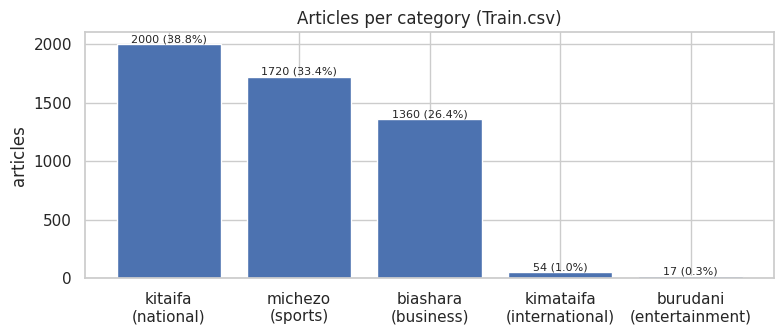

Largest / smallest class = 118 : 1


label,kitaifa,michezo,biashara,kimataifa,burudani
split,,,,,
test,300,258,204,8,3
train,1400,1204,952,38,11
val,300,258,204,8,3


In [6]:
counts = df.label.value_counts().reindex(C.CLASSES)
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar([f"{c}\n({C.ENGLISH[c]})" for c in C.CLASSES], counts.values, color="C0")
ax.bar_label(bars, labels=[f"{v} ({v/counts.sum():.1%})" for v in counts.values], fontsize=8)
ax.set_ylabel("articles"); ax.set_title("Articles per category (Train.csv)")
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_class_distribution.png", dpi=150); plt.show()
S["class_counts"] = counts.to_dict()
S["imbalance_ratio"] = float(counts.max() / counts.min())
S["class_counts_per_split"] = df.groupby(["split", "label"]).size().unstack().reindex(columns=C.CLASSES).to_dict("index")
print(f"Largest / smallest class = {S['imbalance_ratio']:.0f} : 1")
display(df.groupby(["split", "label"]).size().unstack().reindex(columns=C.CLASSES))

> **Decision:** The two smallest categories (*kimataifa*, *burudani*) together make up about 1% of the
> data, and validation/test contain only a handful of them. Consequences:
> (1) accuracy is misleading (predicting only the 3 big classes still scores ~99%), so we report
> **macro-F1** next to the official **log loss**; (2) we test **class-weighted loss**; (3) a 15% test
> split (not 10%) keeps a few minority examples, and we report **bootstrap confidence intervals**;
> (4) per-class results for the minority classes must be read as anecdotal.

## 3 · Text quality: glued sentences, case and numbers

In [7]:
glued = raw.content.map(lambda t: len(GLUED.findall(t)))
toks_raw = raw.content.str.split()
n_upper = toks_raw.map(lambda ts: sum(t.isupper() and len(t) > 2 for t in ts))
num_share = raw.content.map(lambda t: len(tokenize(t)) and tokenize(t).count("<num>") / len(tokenize(t)))
S.update(frac_docs_with_glued=float((glued > 0).mean()), mean_glued_per_doc=float(glued.mean()),
         frac_docs_with_allcaps_word=float((n_upper > 0).mean()), mean_num_token_share=float(num_share.mean()))
print(f"{(glued > 0).mean():.1%} of articles contain sentences glued at punctuation "
      f"(mean {glued.mean():.1f} per article), e.g.:")
ex = raw.content[glued.idxmax()]
m = GLUED.search(ex); print("   ...", ex[max(0, m.start() - 40): m.end() + 40], "...")
print(f"{(n_upper > 0).mean():.1%} of articles contain an ALL-CAPS word (newspaper style for the first word)")
print("Number share of tokens by class:\n", num_share.groupby(raw.label).mean().round(4).to_string())

96.0% of articles contain sentences glued at punctuation (mean 5.9 per article), e.g.:
   ... erikali lakini pia mazingira ya biashara.Alisema lengo la mkutano huo ilikuwa ni  ...
86.0% of articles contain an ALL-CAPS word (newspaper style for the first word)
Number share of tokens by class:
 label
biashara     0.0166
burudani     0.0272
kimataifa    0.0222
kitaifa      0.0186
michezo      0.0254


> **Decision:** Without repair, "yoyote.Hayo" would become a single unseen token. `clean()` inserts the
> missing space, lower-cases, and maps numbers to `<num>`, which keeps the signal that numbers matter
> (scores in sports, amounts in business) without thousands of one-off tokens.

## 4 · Sequence length: how long are articles, and what does truncation cost?

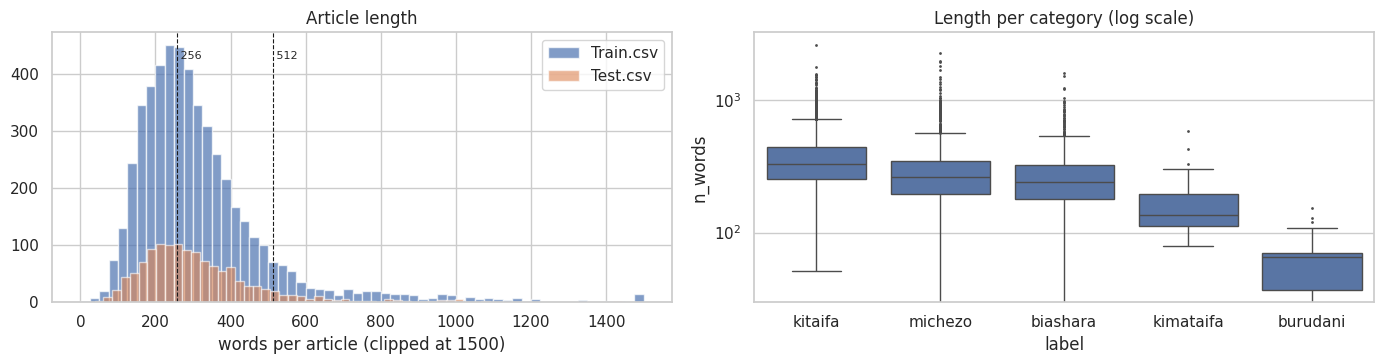

count    5151.0
mean      322.1
std       196.7
min         0.0
50%       278.0
90%       514.0
95%       695.0
99%      1108.0
max      2599.0
Share of articles fully covered by a window of L words: {128: '5.3%', 256: '42.3%', 512: '89.9%', 1024: '98.6%'}
Empty / near-empty articles: 3


In [8]:
tok = df.content.map(tokenize)
df["n_words"] = tok.map(len)
zlen = zindi.content.map(lambda t: len(tokenize(t)))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
ax[0].hist(df.n_words.clip(upper=1500), bins=60, alpha=.7, label="Train.csv")
ax[0].hist(zlen.clip(upper=1500), bins=60, alpha=.6, label="Test.csv")
for L in (256, 512):
    ax[0].axvline(L, ls="--", c="k", lw=.8); ax[0].text(L, ax[0].get_ylim()[1] * .9, f" {L}", fontsize=8)
ax[0].set_xlabel("words per article (clipped at 1500)"); ax[0].set_title("Article length"); ax[0].legend()
sns.boxplot(data=df, x="label", y="n_words", order=C.CLASSES, ax=ax[1], fliersize=1)
ax[1].set_yscale("log"); ax[1].set_title("Length per category (log scale)")
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_lengths.png", dpi=150); plt.show()

desc = df.n_words.describe(percentiles=[.5, .9, .95, .99])
cover = {L: float((df.n_words <= L).mean()) for L in (128, 256, 512, 1024)}
S.update(words_per_doc=desc.to_dict(), frac_docs_within=cover, n_empty_docs=int((df.n_words == 0).sum()),
         median_words_per_class=df.groupby("label").n_words.median().to_dict(),
         zindi_words_median=float(zlen.median()))
print(desc.round(1).to_string())
print("Share of articles fully covered by a window of L words:", {k: f"{v:.1%}" for k, v in cover.items()})
print("Empty / near-empty articles:", int((df.n_words < 5).sum()))

> **Decision:** Articles are long for sequence models (median ≈ 270 words, a long right tail).
> Word-level CNN/RNN inputs are truncated at `MAX_WORDS = 512`, which covers about 90% of articles in
> full; 256 is tested as an experiment. Sub-word tokenisers produce roughly 1.5–2× more tokens than
> words, so the transformer's 512-token limit truncates many more articles; we therefore test
> **head-only vs head+tail** truncation. Long sequences also stress RNNs (information must travel
> hundreds of steps), which motivates **attention pooling**.

### Sub-word length (what the transformer actually sees)
Requires internet on Colab (downloads the XLM-R tokenizer). Skipped offline.

In [9]:
try:
    from transformers import AutoTokenizer
    tk = AutoTokenizer.from_pretrained("Davlan/afro-xlmr-base")
    sub = df.content.sample(min(1000, len(df)), random_state=C.SEED).map(lambda t: len(tk(clean(t))["input_ids"]))
    ratio = float((sub / df.loc[sub.index, "n_words"].clip(lower=1)).median())
    S.update(subword_tokens_median=float(sub.median()), subword_per_word=ratio,
             frac_docs_over_512_subwords=float((sub > 512).mean()))
    print(f"Median sub-word tokens: {sub.median():.0f}; {ratio:.2f} tokens per word; "
          f"{(sub > 512).mean():.1%} of articles exceed 512 sub-word tokens")
except Exception as e:
    print("Tokenizer not available here:", type(e).__name__)

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (675 > 512). Running this sequence through the model will result in indexing errors


Median sub-word tokens: 444; 1.62 tokens per word; 38.1% of articles exceed 512 sub-word tokens


## 5 · Vocabulary: size, rare words and morphology
Swahili is agglutinative: one verb carries subject, tense and object as prefixes
(*a-li-ki-soma*, "he/she read it"), so the number of distinct word forms is large.

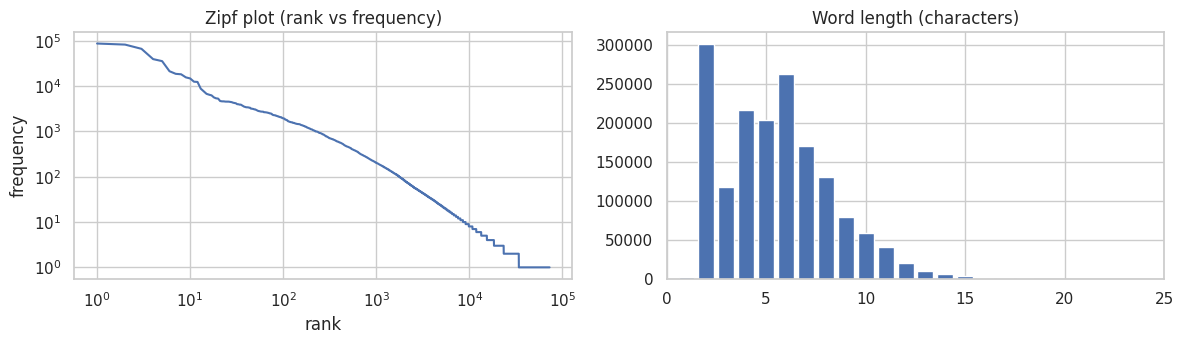

{
 "n_tokens": 1659099,
 "n_types": 72802,
 "hapax_share_of_types": 0.5334880909865114,
 "vocab_size_minfreq2": 26854,
 "val_oov_rate": 0.04681248072576521,
 "val_oov_rate_minfreq1": 0.04091798056766769,
 "mean_word_length": 5.497714180825482
}
Forms containing 'chez' (to play): [('mchezo', 3652), ('wachezaji', 2101), ('michezo', 1540), ('mchezaji', 1528), ('kucheza', 999), ('uliochezwa', 145), ('utakaochezwa', 124), ('itacheza', 112), ('kuchezwa', 92), ('iliyochezwa', 76), ('walicheza', 63), ('kuichezea', 62), ('watacheza', 57), ('wanacheza', 51), ('ilicheza', 51)]


In [10]:
vocab_all = Counter(t for ts in tok for t in ts)
tr_tok, va_tok = tr.content.map(tokenize), va.content.map(tokenize)
V = Vocab(tr_tok)
freqs = np.array(sorted(vocab_all.values(), reverse=True))
S.update(n_tokens=int(freqs.sum()), n_types=len(freqs), hapax_share_of_types=float((freqs == 1).mean()),
         vocab_size_minfreq2=len(V), val_oov_rate=float(V.oov_rate(va_tok)),
         val_oov_rate_minfreq1=float(Vocab(tr_tok, min_freq=1).oov_rate(va_tok)),
         mean_word_length=float(np.mean([len(t) for ts in tok for t in ts if t != "<num>"])))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].loglog(np.arange(1, len(freqs) + 1), freqs); ax[0].set_title("Zipf plot (rank vs frequency)")
ax[0].set_xlabel("rank"); ax[0].set_ylabel("frequency")
lens = Counter(len(t) for ts in tok for t in ts if t != "<num>")
ax[1].bar(list(lens.keys()), list(lens.values())); ax[1].set_xlim(0, 25); ax[1].set_title("Word length (characters)")
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_vocabulary.png", dpi=150); plt.show()
print(json.dumps({k: S[k] for k in ["n_tokens", "n_types", "hapax_share_of_types", "vocab_size_minfreq2",
                                    "val_oov_rate", "val_oov_rate_minfreq1", "mean_word_length"]}, indent=1))

# Morphology example: all forms built on the stem "-cheza" (play)
forms = sorted([(w, c) for w, c in vocab_all.items() if "chez" in w], key=lambda x: -x[1])[:15]
print("Forms containing 'chez' (to play):", forms)
S["example_forms_cheza"] = [w for w, _ in forms]

> **Decision:** A large share of word types occur only once, and many are inflected forms of a few
> stems. A word-level vocabulary (min frequency 2) therefore leaves a noticeable OOV rate on
> validation. Remedies tested: **character n-grams** in the TF-IDF baseline, **pretrained fastText
> vectors** (trained with sub-word information) for the CNN/RNN, and **sub-word tokenisation** in the
> transformer.

## 6 · Most distinctive words per category

In [11]:
tf = TfidfVectorizer(tokenizer=lambda t: tokenize(t), preprocessor=None, lowercase=False, token_pattern=None,
                     min_df=3, sublinear_tf=True)
X = tf.fit_transform(tr.content)
terms = np.array(tf.get_feature_names_out())
rows = {}
for c in C.CLASSES:
    m = (tr.label == c).values
    diff = np.asarray(X[m].mean(0)).ravel() - np.asarray(X[~m].mean(0)).ravel()
    rows[c] = list(terms[np.argsort(-diff)[:12]])
top = pd.DataFrame(rows)
top.to_csv(EDA / "top_terms_per_class.csv", index=False)
S["top_terms"] = {c: rows[c][:8] for c in C.CLASSES}
display(top)

,kitaifa,michezo,biashara,kimataifa,burudani
0,serikali,timu,biashara,rais,up
1,wananchi,mchezo,bidhaa,virusi,mrembo
2,magufuli,ligi,uwekezaji,china,miss
3,rais,simba,benki,marekani,mwanamuziki
4,wilaya,mechi,viwanda,mugabe,google
5,waziri,wachezaji,huduma,kiongozi,brown
6,sheria,yanga,kampuni,trump,urembo
7,wanafunzi,kocha,wateja,corona,ameshinda
8,elimu,mabao,wafanyabiashara,kura,awards
9,dk,dhidi,fursa,saa,world


## 7 · How similar are the categories? (predicting confusions)

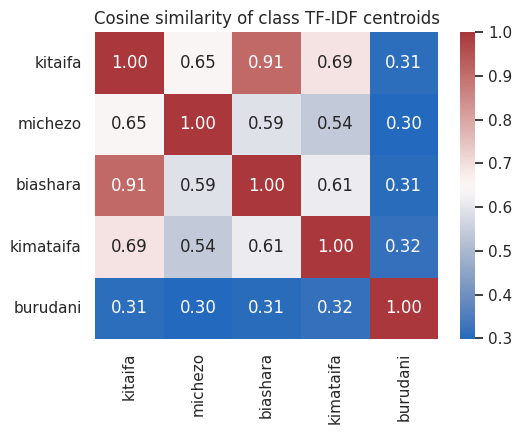

kitaifa   biashara     0.910
          kimataifa    0.693
          michezo      0.646
biashara  kimataifa    0.612


In [12]:
cent = np.vstack([np.asarray(X[(tr.label == c).values].mean(0)) for c in C.CLASSES])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)
sim = pd.DataFrame(cent @ cent.T, index=C.CLASSES, columns=C.CLASSES)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(sim, annot=True, fmt=".2f", cmap="vlag", ax=ax); ax.set_title("Cosine similarity of class TF-IDF centroids")
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_class_similarity.png", dpi=150); plt.show()
pairs = sim.where(np.triu(np.ones(sim.shape, bool), 1)).stack().sort_values(ascending=False)
S["most_similar_pairs"] = {f"{a} / {b}": round(float(v), 3) for (a, b), v in pairs.head(4).items()}
print(pairs.head(4).round(3).to_string())

> **Decision:** National (*kitaifa*) and business (*biashara*) news share government and economy
> vocabulary, and international news overlaps with national politics, so these are the expected
> confusions. Here **context and word order** should help: "Waziri wa Fedha" (Minister of Finance) in
> a budget story vs. in a policy speech. This is where sequential models should beat a bag of words.

## 8 · Where in the article is the category signal? (sequential structure of news)
News is written as an "inverted pyramid": the most important facts come first. We measure where the
category's distinctive words appear, as relative position in the article.

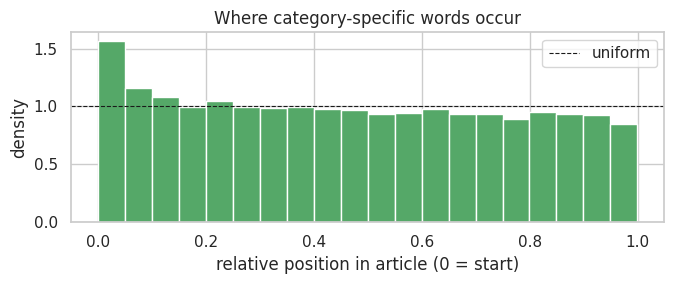

29.2% of category keywords fall in the first quarter (25% if uniform)


In [13]:
key = {c: set(rows[c][:30]) for c in C.CLASSES}
pos = []
for t, l in zip(tr_tok, tr.label):
    n = len(t)
    pos += [i / n for i, w in enumerate(t) if w in key[l]] if n else []
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(pos, bins=20, density=True, color="C2"); ax.axhline(1, ls="--", c="k", lw=.8, label="uniform")
ax.set_xlabel("relative position in article (0 = start)"); ax.set_ylabel("density")
ax.set_title("Where category-specific words occur"); ax.legend()
fig.tight_layout(); fig.savefig(C.FIG_DIR / "eda_keyword_position.png", dpi=150); plt.show()
S["keyword_share_first_quarter"] = float(np.mean(np.array(pos) < .25))
print(f"{S['keyword_share_first_quarter']:.1%} of category keywords fall in the first quarter (25% if uniform)")

> **Decision:** If keywords concentrate early, head truncation loses little; if they are spread out
> or appear at the end (e.g. a closing summary), head+tail truncation should help. This is tested
> directly in BL-04/BL-05 (first vs last 128 words) and TR-03 (head+tail).

## 9 · Duplicates, near-duplicates and code-switching

In [14]:
norm = df.content.map(clean)
dup_exact = int(norm.duplicated(keep=False).sum())
prefix = norm.str[:200]
dup_prefix = df[prefix.duplicated(keep=False)]
cross = dup_prefix.groupby(prefix[dup_prefix.index]).split.nunique()
conflict = dup_prefix.groupby(prefix[dup_prefix.index]).label.nunique()
eng = tok.map(lambda ts: sum(t in ENGLISH_STOP_WORDS for t in ts) / max(len(ts), 1))
S.update(n_exact_duplicates=dup_exact, n_near_duplicate_docs=int(len(dup_prefix)),
         near_dup_groups_across_splits=int((cross > 1).sum()), near_dup_groups_conflicting=int((conflict > 1).sum()),
         english_function_word_share_mean=float(eng.mean()), frac_docs_english_over_5pct=float((eng > .05).mean()))
print(f"Exact duplicates: {dup_exact}; articles sharing their first 200 characters: {len(dup_prefix)} "
      f"({(cross > 1).sum()} groups across splits, {(conflict > 1).sum()} with conflicting labels)")
print(f"English function words: mean share {eng.mean():.2%}; {(eng > .05).mean():.1%} of articles above 5%")
print("Example with the most English:\n", df.content[eng.idxmax()][:300])
dup_prefix[["id", "label", "split"]].assign(prefix=prefix[dup_prefix.index].str[:80]).to_csv(EDA / "near_duplicates.csv", index=False)

Exact duplicates: 10; articles sharing their first 200 characters: 48 (14 groups across splits, 5 with conflicting labels)
English function words: mean share 0.13%; 0.1% of articles above 5%
Example with the most English:
  Mwishoni mwa mwaka jana Diamond alitangaza kufungua radio na kituo cha runinga ambapo alisema zitakuwa zinaitwa Wasafi Radio na TV kwa ajili ya kutoa fursa ya ajira kwa vijana.Kupitia ukurasa wake wa Instagram aliandika “Please tell me, from your perspective which city has the best Radio and Tv pre


> **Decision:** Near-duplicates across splits inflate test scores; conflicting labels are label noise
> that log loss punishes heavily. Both are listed in `results/eda/near_duplicates.csv` and revisited
> in error analysis. English code-switching is light (mostly names of organisations and quoted
> English), so a Swahili/African-language model is appropriate; multilingual pretraining still helps
> with English fragments.

## 10 · Save the summary for the report

In [15]:
(EDA / "eda_summary.json").write_text(json.dumps(S, indent=2, default=str))
print(json.dumps(S, indent=1, default=str)[:4000])

{
 "n_train_csv": 5151,
 "n_zindi_test": 1288,
 "split_sizes": {
  "train": 3605,
  "test": 773,
  "val": 773
 },
 "raw_label_spellings": {
  "Kitaifa": 2000,
  "michezo": 1720,
  "Biashara": 1360,
  "Kimataifa": 54,
  "Burudani": 17
 },
 "class_counts": {
  "kitaifa": 2000,
  "michezo": 1720,
  "biashara": 1360,
  "kimataifa": 54,
  "burudani": 17
 },
 "imbalance_ratio": 117.6470588235294,
 "class_counts_per_split": {
  "test": {
   "kitaifa": 300,
   "michezo": 258,
   "biashara": 204,
   "kimataifa": 8,
   "burudani": 3
  },
  "train": {
   "kitaifa": 1400,
   "michezo": 1204,
   "biashara": 952,
   "kimataifa": 38,
   "burudani": 11
  },
  "val": {
   "kitaifa": 300,
   "michezo": 258,
   "biashara": 204,
   "kimataifa": 8,
   "burudani": 3
  }
 },
 "frac_docs_with_glued": 0.9598136284216657,
 "mean_glued_per_doc": 5.9336051252184046,
 "frac_docs_with_allcaps_word": 0.8598330421277421,
 "mean_num_token_share": 0.02043191450673187,
 "words_per_doc": {
  "count": 5151.0,
  "mean": 32

In [16]:
from src.utils import persist_outputs
persist_outputs()

Outputs copied to /content/drive/MyDrive/swahili-news/outputs


In [17]:
!ls /content/*.ipynb
!ls /content/swahili-news-sequential/notebooks/
!ls /content/swahili-news-sequential/

ls: cannot access '/content/*.ipynb': No such file or directory
01_eda.ipynb	    04_birnn_attention.ipynb
02_baselines.ipynb  05_transformer.ipynb
03_textcnn.ipynb    06_compare_and_error_analysis.ipynb
CONTRIBUTIONS.md  experiments  README.md	 results  submissions
data		  notebooks    requirements.txt  src	  tests
